## **Chapter 2: Filtering Points on Qdrant**

Learn how to **Filter** individual points in a Qdrant collection.

In [ ]:
!pip install -q qdrant-client sentence-transformers

In [ ]:
from qdrant_client import QdrantClient, models
from qdrant_client.models import (
    Distance, VectorParams, PointStruct,
    Filter, FieldCondition, MatchValue,
)

client = QdrantClient(path="/tmp/my_qdrant")

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
DIM   = model.get_sentence_embedding_dimension()
print(f"Embedding dimension: {DIM}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding dimension: 384


/tmp/ipykernel_3844/1824897786.py:4: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  DIM   = model.get_sentence_embedding_dimension()


### **Create a Qdrant Collection**

In [ ]:
COLLECTION_NAME = "my_collection"

def create_collection(name: str, distance: models.Distance):
    if not client.collection_exists(collection_name=name):
        client.create_collection(
            collection_name=name,
            vectors_config=models.VectorParams(size=DIM, distance=distance)
        )
        print(f"Collection '{name}' created successfully.")
    else:
        print(f"Collection '{name}' already exists.")

create_collection(COLLECTION_NAME, models.Distance.COSINE)

Collection 'my_collection' already exists.


You can also index JSON in a Qdrant collection.

In [ ]:
# Sample Documents
documents = [
    {"id": 1, "text": "Dogs are loyal and friendly domestic animals.",
     "category": "animal", "role": "public"},
    {"id": 2, "text": "Cats are independent and curious creatures.",
     "category": "animal", "role": "public"},
    {"id": 3, "text": "Quantum computing uses qubits to perform complex calculations.",
     "category": "technology", "role": "admin"},
    {"id": 4, "text": "Machine learning enables computers to learn from data.",
     "category": "technology", "role": "public"},
    {"id": 5, "text": "The Milky Way galaxy contains over 200 billion stars.",
     "category": "science", "role": "public"},
    {"id": 6, "text": "Nuclear fusion is the process powering the sun.",
     "category": "science", "role": "admin"},
]

In [ ]:
texts    = [doc["text"] for doc in documents]
vectors  = model.encode(texts)

print(texts[0])
print(vectors[0])

Dogs are loyal and friendly domestic animals.
[-3.66339684e-02 -3.29478905e-02  2.27336865e-02  6.64364398e-02
 -5.36165647e-02  2.27458384e-02 -2.11714953e-02 -8.27348605e-02
  3.22350785e-02  4.99559790e-02  5.67642637e-02 -5.34846410e-02
  3.14257853e-02  4.75938544e-02  3.20098400e-02  2.32356787e-02
 -2.29435805e-02 -4.77748774e-02 -2.09068246e-02 -2.32111150e-03
 -1.37930825e-01 -2.33906116e-02  1.77906044e-02  7.32444110e-04
 -6.37915134e-02  1.69086102e-02  5.82160391e-02 -5.05699664e-02
  2.01622508e-02 -8.60782992e-03 -2.66483091e-02 -3.64649519e-02
  4.23132740e-02  1.81325115e-02 -7.42081851e-02  9.70794121e-04
 -5.28580137e-03  2.78006829e-02  1.63985584e-02  4.56886664e-02
  2.00761128e-02 -5.17774150e-02  6.47104681e-02 -7.60742798e-02
 -6.30132630e-02  2.71923840e-02 -9.39279050e-02 -2.33154707e-02
 -1.14535680e-02 -5.63323982e-02  1.98285747e-02  5.63527271e-02
  1.22260361e-03  1.21251112e-02  1.27016865e-02 -4.80139628e-02
 -2.83544306e-02 -2.07986217e-02  8.66120402

### **Creating Points with Payload (Qdrant's Datastructure)**

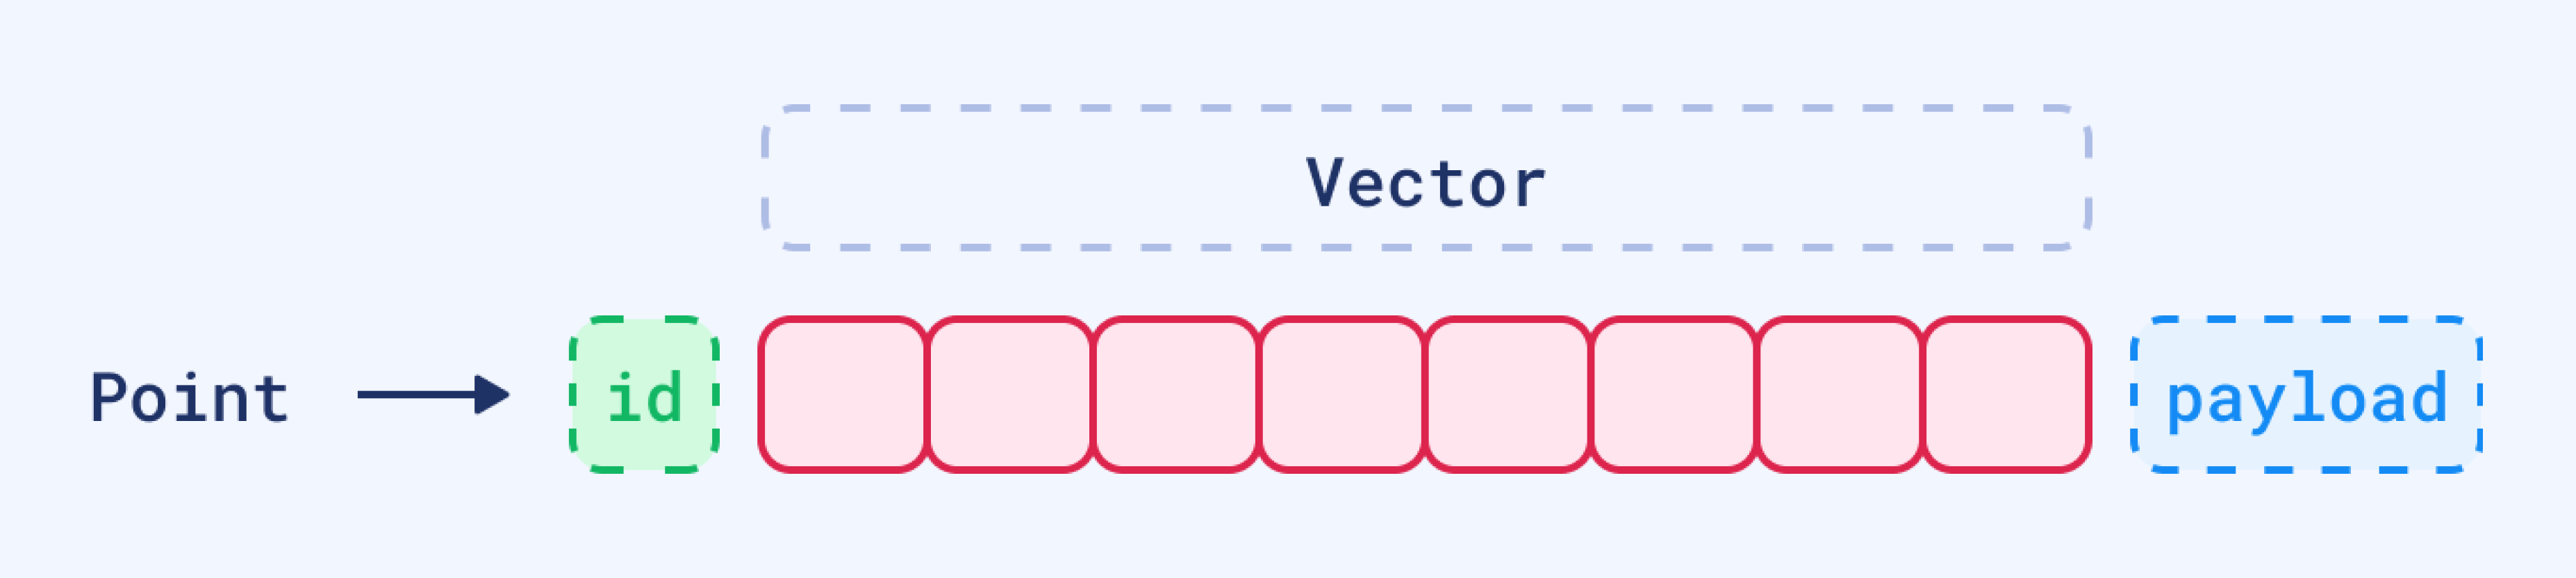

In [ ]:
points = [
    models.PointStruct(
        id      = doc["id"],
        vector  = vectors[i].tolist(),
        payload = {
            "text"    : doc["text"],
            "category": doc["category"],
            "role"    : doc["role"],
        }
    )
    for i, doc in enumerate(documents)
]

### **Insert Points in Qdrant**
Qdrant's `upsert` function inserts new points into a collection or updates existing points if the same point IDs already exist.

It enables efficient synchronization of vector data by combining insert and update operations into a single request.


In [ ]:
operation_info = client.upsert(
    collection_name="my_collection",
    wait=True,
    points=points
)

print(f"Status: {operation_info.status}")

Status: completed


In [ ]:
query     = "What animals make good pets?"
query_vec = model.encode(query).tolist()

results = client.query_points(
    collection_name="my_collection",
    query=query_vec,
    limit=3,
    #score_threshold=0.35
)


In [ ]:
for r in results.points:
    print(f"Score: {r.score:.4f} | {r.payload['text']}")

Score: 0.5665 | Dogs are loyal and friendly domestic animals.
Score: 0.3954 | Cats are independent and curious creatures.
Score: 0.0436 | Nuclear fusion is the process powering the sun.


## **Payload Filtering**

Combine vector similarity with **metadata filters** to get precise, relevant results.

| Operator | Meaning |
|---|---|
| `must` | AND – all conditions must match |
| `should` | OR – at least one condition must match |
| `must_not` | NOT – conditions must NOT match |
---

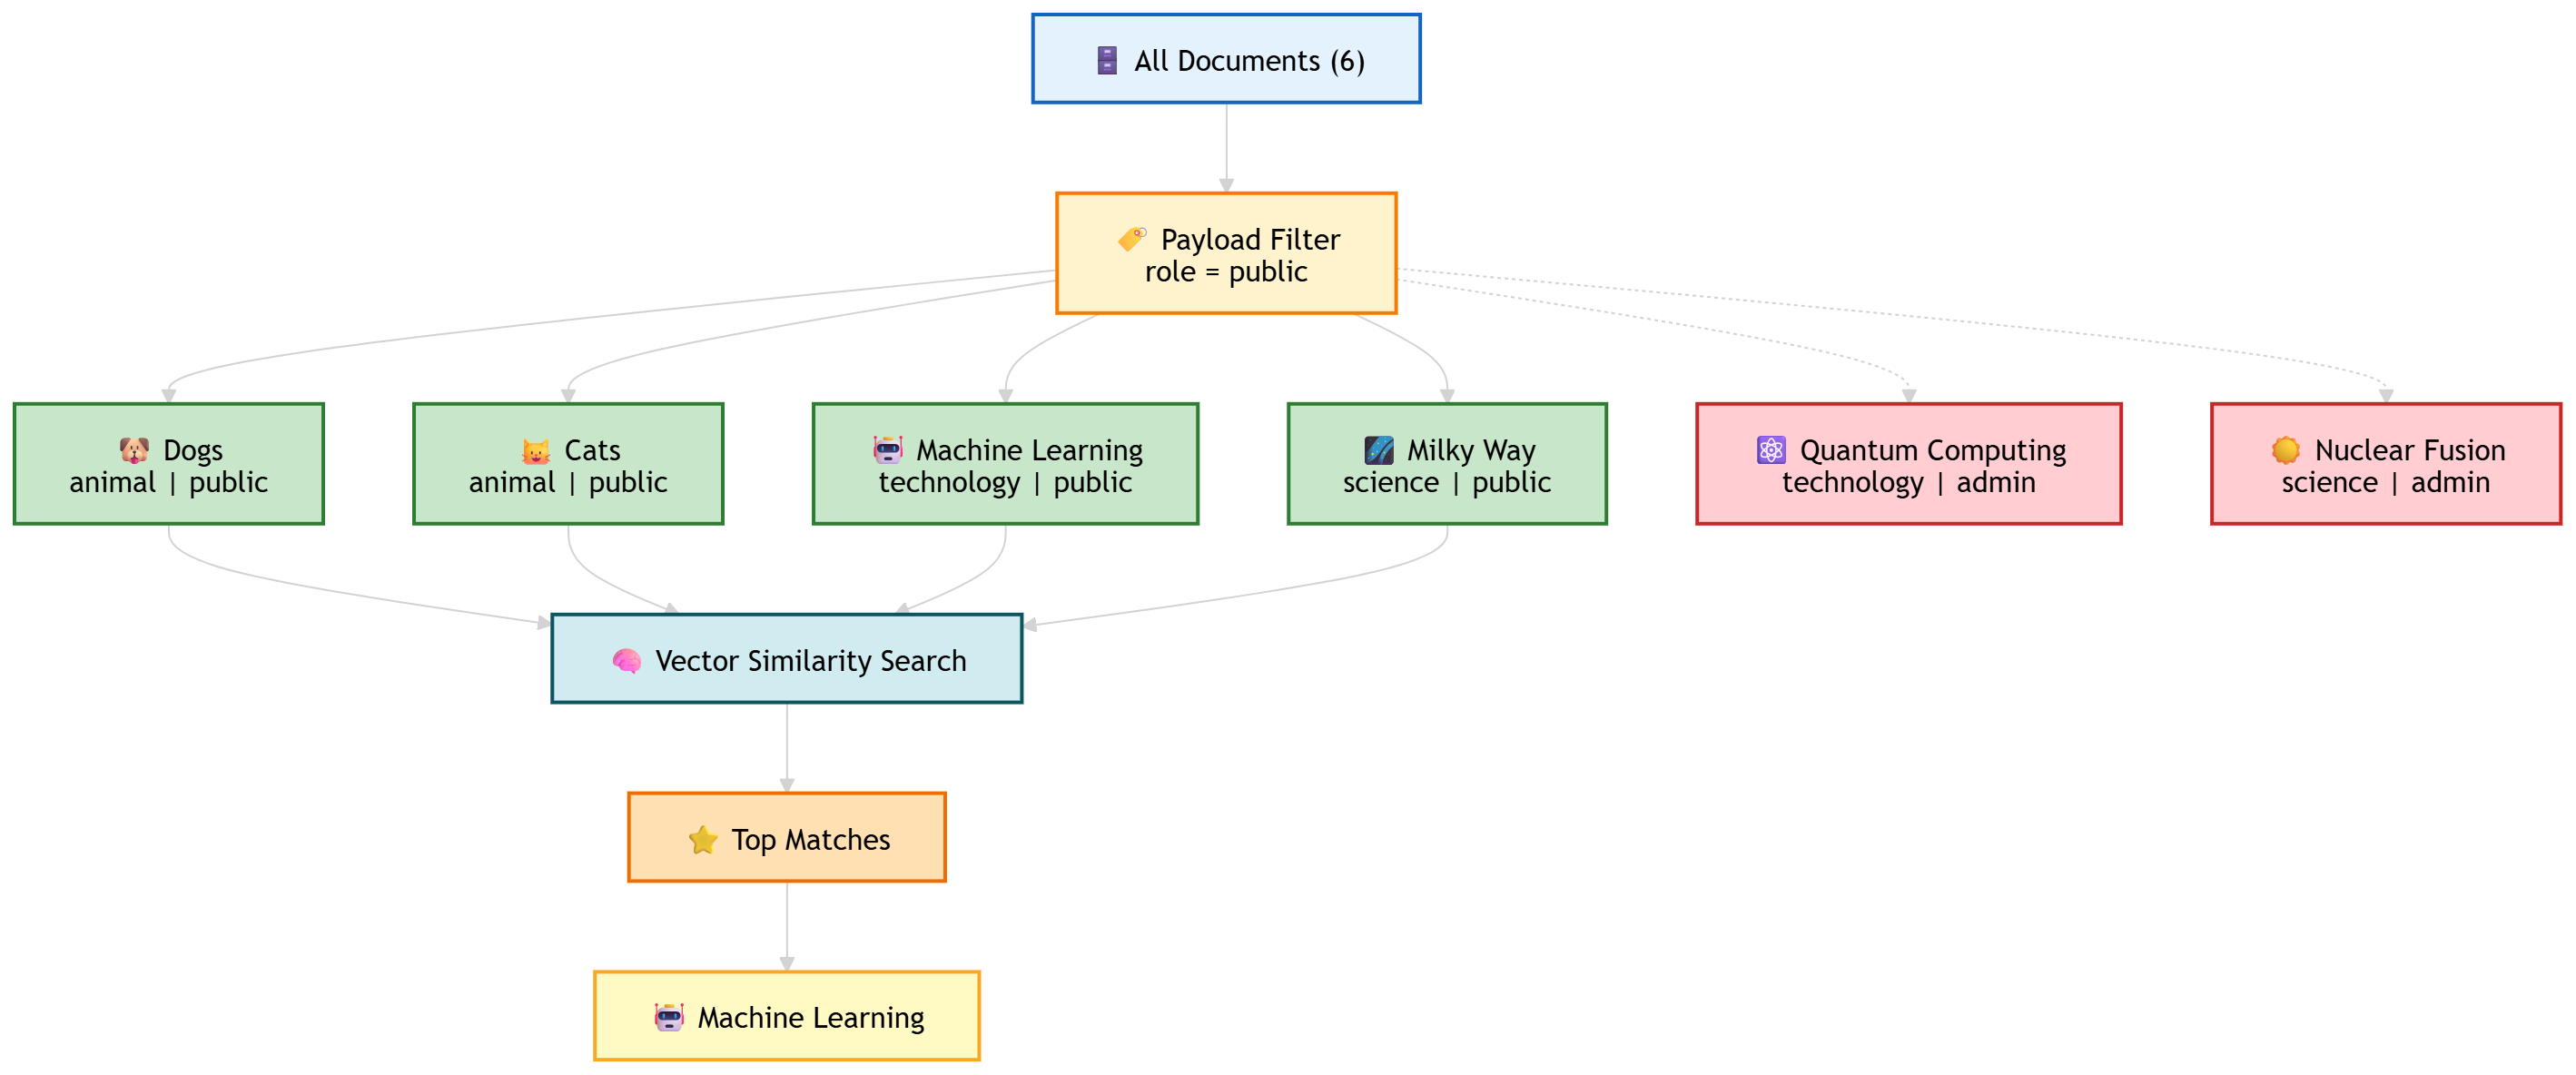

### **`must` Filtering: Filtering by Exact Match**

In [ ]:
results = client.query_points(
    collection_name="my_collection",
    query=model.encode("computers and learning").tolist(),
    query_filter=Filter(
        must=[
            FieldCondition(
                key="category",
                match=MatchValue(value="technology")
            )
        ]
    ),
    limit=3
)

for r in results.points:
    print(f"Score: {r.score:.4f} | {r.payload['text'][:60]}")

Score: 0.5866 | Machine learning enables computers to learn from data.
Score: 0.2587 | Quantum computing uses qubits to perform complex calculation


### **Filtering with multiple conditions**

Remember: `must` = **AND**,  `should` = **OR**,  `must_not` = **NOT**

In [ ]:
results = client.query_points(
    collection_name="my_collection",
    query=model.encode("astronomy and stars").tolist(),
    query_filter=Filter(
        must=[
            FieldCondition(key="category", match=MatchValue(value="science")),
            FieldCondition(key="role",     match=MatchValue(value="public"))
        ]
    ),
    limit=5
)
for r in results.points:
    print(f"Score: {r.score:.4f} | {r.payload['text'][:60]}")

Score: 0.3869 | The Milky Way galaxy contains over 200 billion stars.
